         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  2012-09-04       58       635  ...            

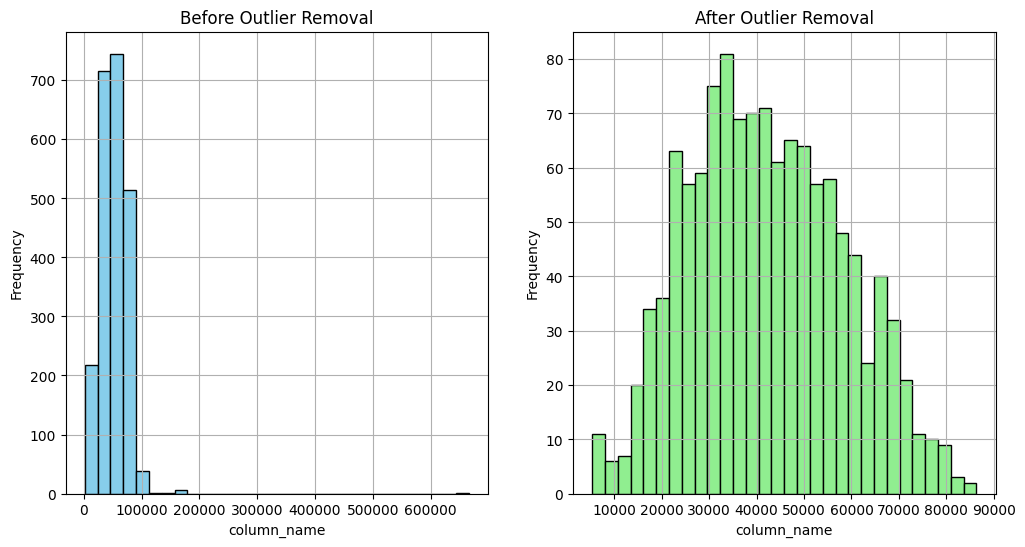

     ID  Year_Birth   Income  Kidhome  Teenhome Dt_Customer  Recency  \
0  5524        1957  58138.0        0         0  2012-09-04       58   
1  2174        1954  46344.0        1         1  2014-03-08       38   
2  4141        1965  71613.0        0         0  2013-08-21       26   
3  6182        1984  26646.0        1         0  2014-02-10       26   
4  5324        1981  58293.0        1         0  2014-01-19       94   

   MntWines  MntFruits  MntMeatProducts  ...  Marital_Status_Alone  \
0  0.425318   0.442211         0.316522  ...                 False   
1  0.007368   0.005025         0.003478  ...                 False   
2  0.285332   0.246231         0.073623  ...                 False   
3  0.007368   0.020101         0.011594  ...                 False   
4  0.115874   0.216080         0.068406  ...                 False   

   Marital_Status_Divorced  Marital_Status_Married  Marital_Status_Single  \
0                    False                   False                   

In [ ]:
import pandas as pd
df = pd.read_excel("/content/marketing_campaign.xlsx")
print(df)
print (df.isnull().sum())
print (df.columns)
df['Income']= df['Income'].fillna(df['Income'].median())
print(df['Income'])
print (df.isnull().sum())
df['Dt_Customer']= pd.to_datetime(df['Dt_Customer'])
df.dtypes
df = pd.get_dummies (df,columns=['Education','Marital_Status'])
print(df.head())
df['Total Spend'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
print (df['Total Spend'])
print(df)
df['Total_Purchases']= df['NumWebPurchases']+ df['NumCatalogPurchases']+df['NumStorePurchases']
df['Total_Purchases']
df['ROI']=((df['Z_Revenue'] - df['Z_CostContact']) / df['Z_CostContact'])*100
print(df['ROI'])
print(df)
print("Duplicates found:",df.duplicated().sum())
df = df.drop_duplicates()
df.dtypes
import numpy as np
numeric_cols = df.select_dtypes(include=[np.number])
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((numeric_cols < (Q1 - 1.5 * IQR)) | (numeric_cols > (Q3 + 1.5 * IQR)))
outlier_counts_per_column = outlier_mask.sum()
total_outlier_rows = outlier_mask.any(axis=1).sum()
df_filtered = df[~outlier_mask.any(axis=1)]
print("Outlier counts per numeric column:")
print(outlier_counts_per_column)
print("\nTotal number of rows with at least one outlier:", total_outlier_rows)
print("\nNumber of rows after removing outliers:",df_filtered.shape[0])
import matplotlib.pyplot as plt
column_name = 'Income'
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
df[column_name].hist(ax=ax[0], bins=30, color='skyblue', edgecolor='black')
ax[0].set_title('Before Outlier Removal')
ax[0].set_xlabel('column_name')
ax[0].set_ylabel('Frequency')
df_filtered[column_name].hist(ax=ax[1], bins=30, color='lightgreen', edgecolor='black')
ax[1].set_title('After Outlier Removal')
ax[1].set_xlabel('column_name')
ax[1].set_ylabel('Frequency')
plt.show()
from sklearn.preprocessing import MinMaxScaler
expenditure_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
scaler = MinMaxScaler()
df[expenditure_columns] = scaler.fit_transform(df[expenditure_columns])
print(df.head())
print (df[expenditure_columns].describe())
df_filtered.to_csv("/content/marketing_campaign_processed.csv",index=False)

